# Active-set-aware parametric sensitivity

An advanced-step NMPC controller solves the next optimization ahead of
time, from the state it predicts the plant will reach, and holds the
solve's KKT factorization. When the measurement arrives, the controller
corrects the solution for the gap between the predicted and measured
state without solving again. `estimate()` is that correction. It
predicts the re-optimized trajectories from the held factorization.
This notebook is about what the correction does when a control sits at
a limit.

The model is a CSTR (Hicks & Ray 1971) with dimensionless concentration
`zc` and temperature `zt`, a coolant valve `v1` and a residence-time
valve `v2`, both piecewise constant over 100 one-minute sampling
intervals. The solve this notebook holds throughout starts at an upset,
`zc(0) = 0.5216` and `zt(0) = 0.4887`, cold and dilute against the
steady state at `(0.6416, 0.5387)`. The optimal response cuts cooling
to the valve's minimum and holds it there for the first stretch of the
horizon. That active bound is what makes the correction interesting:

1. a plain linear step predicts v1 below its minimum, values no plant
   can execute (`estimate_report` names exactly where that
   happens).
2. `mode="fix_relax"` repairs the prediction, holding v1 at the
   minimum on the intervals where it is saturated and letting the
   rest of the trajectory move consistently, and releasing
   those intervals when the measured state says the valve should
   come off its limit.
3. `mode="path"` applies the change from the predicted state to the
   measured one a little at a time, and
   reports where along the way the active set changes, which
   neither of the other modes can say.

Every experiment below has the same shape:

* the held solve, always the upset above.
* the measured state, one of the four cases in the table below.
* the prediction, one or more `estimate()` calls against the held
  factorization.
* the reference, a full re-solve at the measured state, warm-started
  from the held solution so it continues the same local solution.

All four measured states used below lie on the line from the held
initial state to the steady state:

| case | zc(0) | zt(0) | change in zc(0) | change in zt(0) | fraction of the way |
|---|---|---|---|---|---|
| A | 0.4916 | 0.4762 | -0.0300 | -0.0125 | -25% |
| B | 0.5516 | 0.5012 | +0.0300 | +0.0125 | +25% |
| C | 0.5816 | 0.5137 | +0.0600 | +0.0250 | +50% |
| D | 0.6416 | 0.5387 | +0.1200 | +0.0500 | +100% |

Each figure is titled with the case it uses.

Case E, in section 7, is deliberately not in that table. The four
above share a base point and differ only in how far the measured
state moves from it. Case E moves the base point instead. It holds a
solve at the state 1.3% along the same line, where the record's first
entry says the active set changes, and takes a small measured step
from there. That is what `degeneracy` needs to have anything to say,
since a base point on a kink is the only place the two one-sided
derivatives differ, and none of A through D is on one.


In [1]:
import platform
import subprocess
import warnings
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pyomo.environ as pyo
from matplotlib import cm

import pyomo_pounce  # registers 'pounce' with SolverFactory
from pyomo_pounce import estimate, estimate_report
from pounce.examples.asnmpc_cstr import (
    BASE_STATE, MODEL_REVISION, V1_MIN, V1_SS, V2_SS, ZC_SS, ZT_SS,
    CstrConfig, build_controller,
)

repo_root = next(
    root for root in (Path.cwd(), *Path.cwd().parents)
    if (root / "Cargo.toml").exists()
)
SOURCE_COMMIT = subprocess.check_output(
    ["git", "rev-parse", "HEAD"], cwd=repo_root, text=True
).strip()
VERSIONS = {name: version(name) for name in (
    "pounce-solver", "pyomo", "pyomo-cvp", "pyomo-pounce",
    "numpy", "matplotlib",
)}

print(f"POUNCE {VERSIONS['pounce-solver']}; source commit {SOURCE_COMMIT}")
print(f"model revision {MODEL_REVISION}")
print(f"runtime Python {platform.python_version()}; {platform.platform()} "
      f"[{platform.machine()}]")
print("dependencies " + ", ".join(
    f"{name} {value}" for name, value in VERSIONS.items()
))


POUNCE 0.10.0; source commit 496bc28cbe32dbad986211af2bfaf9448be97f96
model revision hicks-ray-collocation-asnmpc-v1
runtime Python 3.13.5; Linux-6.6.114.1-microsoft-standard-WSL2-x86_64-with-glibc2.39 [x86_64]
dependencies pounce-solver 0.10.0, pyomo 6.10.1, pyomo-cvp 0.7.2, pyomo-pounce 0.10.0, numpy 2.4.5, matplotlib 3.11.1


## 1. The base solution

With the reactor cold, the controller cuts cooling to the valve's
minimum and holds it there, letting the exotherm reheat the
reactor, then eases cooling back in as the state approaches the
target. The shaded band is the stretch where `v1` sits
at its minimum, which is the active set this notebook is about.


In [2]:
N, H = 100, 1  # 100 sampling intervals of 1 minute
OPEN_LOOP_CONFIG = CstrConfig(
    horizon_intervals=N, sample_time_min=H, collocation_points=3,
    temperature_limit=1.0, solver_tol=1e-8,
)


def build(zc0, zt0):
    return build_controller((zc0, zt0), OPEN_LOOP_CONFIG)


def solve(m, tee=False):
    res = pyo.SolverFactory("pounce").solve(m, tee=tee,
                                            options={"tol": 1e-8})
    assert str(res.solver.termination_condition) == "optimal"
    return m


# the base case starts at an upset, colder and more dilute than the target
BASE = BASE_STATE
base = solve(build(*BASE))

def v1_profile(m, source=None):
    keys = sorted(k for k, _ in m.v1.items())
    if source is None:
        vals = [pyo.value(m.v1[k]) for k in keys]
    else:
        vals = [source[m.v1[k]] for k in keys]
    return np.asarray(keys, float), np.asarray(vals, float)

def state_profile(m, var, source=None):
    keys = sorted(m.t)
    if source is None:
        vals = [pyo.value(var[k]) for k in keys]
    else:
        vals = [source[var[k]] for k in keys]
    return np.asarray(keys, float), np.asarray(vals, float)

tk, v1b = v1_profile(base)
sat = v1b < V1_MIN + 1e-4
print(f"valve v1 at its minimum for {sat.sum()} of {len(v1b)} intervals "
      f"(the first {sat[:int(sat.sum()) + 2].sum()} of the horizon)")


def v2_profile(m, source=None):
    keys = sorted(k for k, _ in m.v2.items())
    if source is None:
        vals = [pyo.value(m.v2[k]) for k in keys]
    else:
        vals = [source[m.v2[k]] for k in keys]
    return np.asarray(keys, float), np.asarray(vals, float)


def panels(entries, xlim=40, v1_extra=None, title=None):
    """One 2x2 figure: both states on top, both valves below.

    entries: (label, model, est, kwargs). est is None to read the
    model's own values, or an estimate() result read on the base
    model's variables.
    """
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    for label, m, est, kw in entries:
        t, zc = state_profile(m, m.zc, est)
        axes[0, 0].plot(t, zc, label=label, **kw)
        t, zt = state_profile(m, m.zt, est)
        axes[0, 1].plot(t, zt, label=label, **kw)
        t, v1 = v1_profile(m, est)
        axes[1, 0].step(t, v1, where="post", label=label, **kw)
        t, v2 = v2_profile(m, est)
        axes[1, 1].step(t, v2, where="post", label=label, **kw)
    if v1_extra is not None:
        t, v, lab = v1_extra
        axes[1, 0].step(t, v, where="post", color="tab:orange", lw=1,
                        ls=":", label=lab)
    axes[1, 0].axhline(V1_MIN, color="crimson", lw=1, ls="--")
    for ax, name in zip(axes.flat, ("zc, concentration", "zt, temperature",
                                    "v1, coolant valve",
                                    "v2, residence-time valve")):
        ax.set_title(name)
        ax.set_xlim(0, xlim)
    for ax in axes[1]:
        ax.set_xlabel("time (min)")
    axes[0, 0].legend(fontsize=8)
    if title is not None:
        fig.suptitle(title)
        fig.tight_layout(rect=(0, 0, 1, 0.96))
    else:
        fig.tight_layout()
    plt.show()


valve v1 at its minimum for 13 of 100 intervals (the first 13 of the horizon)


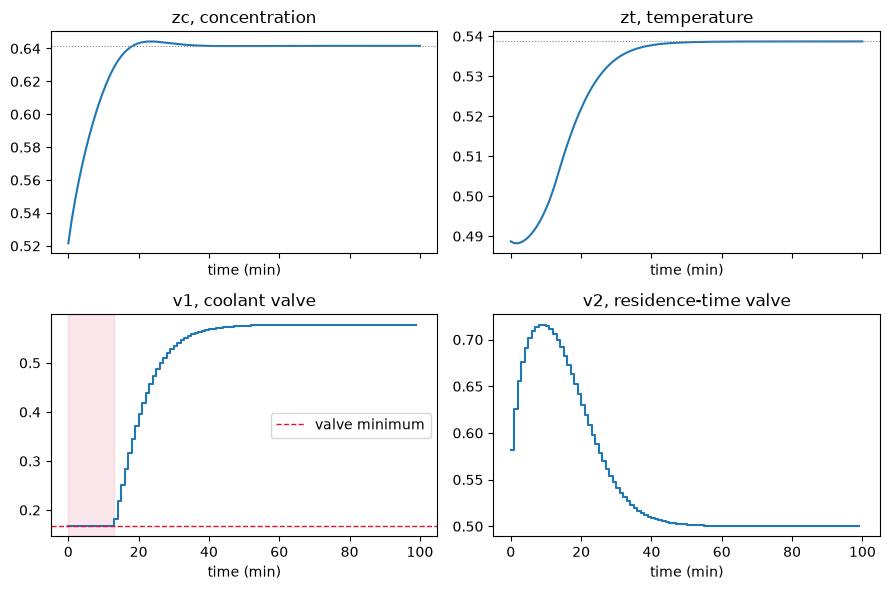

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6), sharex=True)
for ax, (var, ss, name) in zip(
        axes.flat[:2],
        [(base.zc, ZC_SS, "zc, concentration"),
         (base.zt, ZT_SS, "zt, temperature")]):
    t, x = state_profile(base, var)
    ax.plot(t, x)
    ax.axhline(ss, color="gray", lw=0.8, ls=":")
    ax.set_title(name)
ax = axes.flat[2]
ax.step(tk, v1b, where="post")
ax.axhline(V1_MIN, color="crimson", lw=1, ls="--", label="valve minimum")
on = np.where(sat)[0]
if on.size:
    ax.axvspan(tk[on[0]], tk[on[-1]] + H, color="crimson", alpha=0.10)
ax.set_title("v1, coolant valve")
ax.legend()
ax = axes.flat[3]
tk2, v2b = ( np.asarray(sorted(k for k, _ in base.v2.items()), float),
             np.asarray([pyo.value(base.v2[k]) for k in
                         sorted(k for k, _ in base.v2.items())], float))
ax.step(tk2, v2b, where="post")
ax.set_title("v2, residence-time valve")
for ax in axes.flat:
    ax.set_xlabel("time (min)")
fig.tight_layout()
plt.show()


## 2. The measured state is farther from the steady state than predicted

* prediction: `estimate(mode="linear", clamp=True)`, the baseline a
  caller gets without choosing anything
* reference: re-solve at the measured state

The linear step treats v1 in every sampling interval as free to
move, including the 13 intervals where it sits at the minimum. With
`clamp=False` the prediction crosses below the valve minimum (the
thin dotted trace). With `clamp=True` those
values are pulled back to the minimum, so the valve plot looks
plausible. The error is in everything else. Every other predicted
value was computed as though the valve really had gone below its
minimum, so the temperature trajectory that comes with the clamped
v1 values is inconsistent with them. The clamp hides the problem in
the valve plot and moves it into the states.


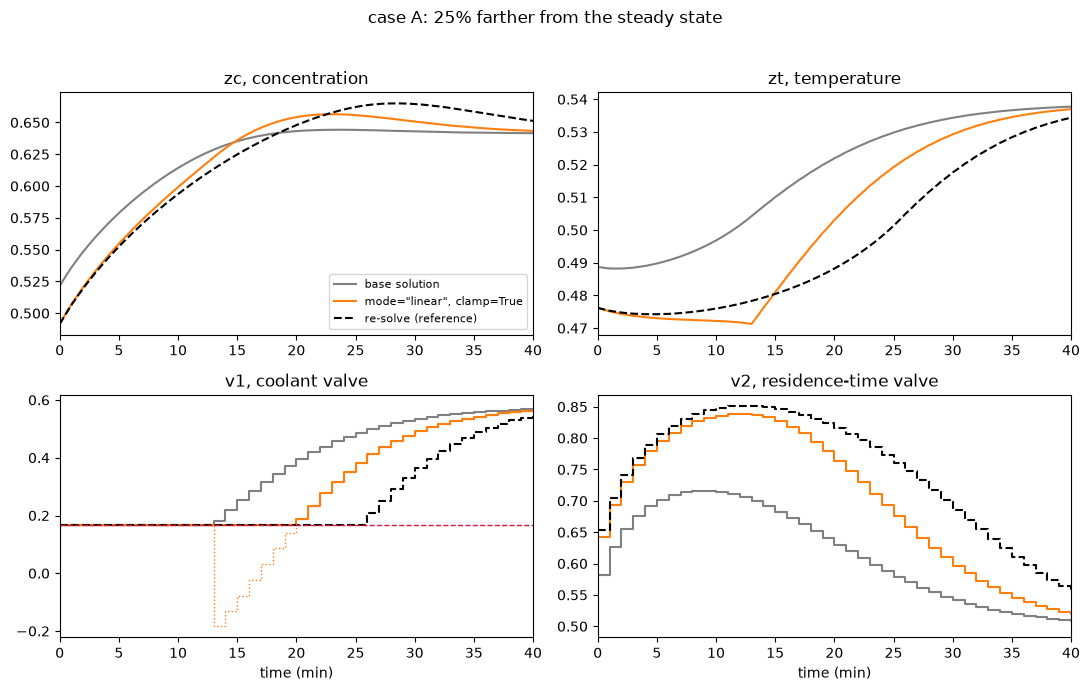

with clamp=False the step predicts v1 below its minimum on 8 intervals, by up to 0.3508. clamp=True pulls them back to the minimum


In [4]:
def warm_resolve(zc0, zt0):
    m = build(zc0, zt0)
    seed = {v.name: pyo.value(v, exception=False)
            for v in base.component_data_objects(pyo.Var, active=True)}
    for v in m.component_data_objects(pyo.Var, active=True):
        sv = seed.get(v.name)
        if sv is not None:
            v.set_value(sv, skip_validation=True)
    return solve(m)

WORSE = (BASE[0] - 0.03, BASE[1] - 0.0125)   # 25% farther out
truth_worse = warm_resolve(*WORSE)
perturb_worse = [(base.zc0, WORSE[0]), (base.zt0, WORSE[1])]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    est_lin = estimate(base, perturb_worse)               # clamp=True
    est_open = estimate(base, perturb_worse, clamp=False)

_, v1_open = v1_profile(base, est_open)
panels([
    ("base solution", base, None, dict(color="gray")),
    ('mode="linear", clamp=True', base, est_lin, dict(color="tab:orange")),
    ("re-solve (reference)", truth_worse, None,
     dict(color="black", ls="--")),
], v1_extra=(tk, v1_open, 'mode="linear", clamp=False'), title='case A: 25% farther from the steady state')

below = v1_open < V1_MIN - 1e-6
print(f"with clamp=False the step predicts v1 below its minimum on "
      f"{below.sum()} intervals, by up to "
      f"{(V1_MIN - v1_open[below]).max():.4f}. clamp=True pulls them "
      "back to the minimum")


`estimate_report()` measures this without fixing it. It runs the same step and reports the first bound crossing:
which variable, which bound, and the fraction of the step at
which the crossing happens. A fraction well below 1 says the
linear prediction is only trustworthy for a fraction of the gap between
predicted and measured state.


In [5]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    rep = estimate_report(base, [(base.zc0, WORSE[0]),
                                 (base.zt0, WORSE[1])])
print(rep)


EstimateReport(alpha=0.0434554, first variable v1[13.0], crossed=20, violation=1.125e-03, mu=2.506e-09)


## 3. Repairing the prediction: `mode="fix_relax"`

* prediction: `estimate(mode="fix_relax")`
* reference: the same re-solve

Where the clamp forces each crossing v1 value back to the minimum
and leaves every other value untouched, `mode="fix_relax"` pins the
crossing v1 value at the minimum and re-solves the system with that
pin, so every other prediction moves consistently with the valve actually
sitting at its limit. This is sIPOPT's fix-relax, run against the same
held factorization.

The number printed under each figure from here on is the
prediction's largest error. Every value of the four predicted
trajectories is compared with the re-solve's value, the difference
is divided by that value (floored at 0.01 so values near zero do
not inflate the ratio), and the largest result is reported. An
error of 0.01 means the worst predicted value is 1% away from the
re-solve's.


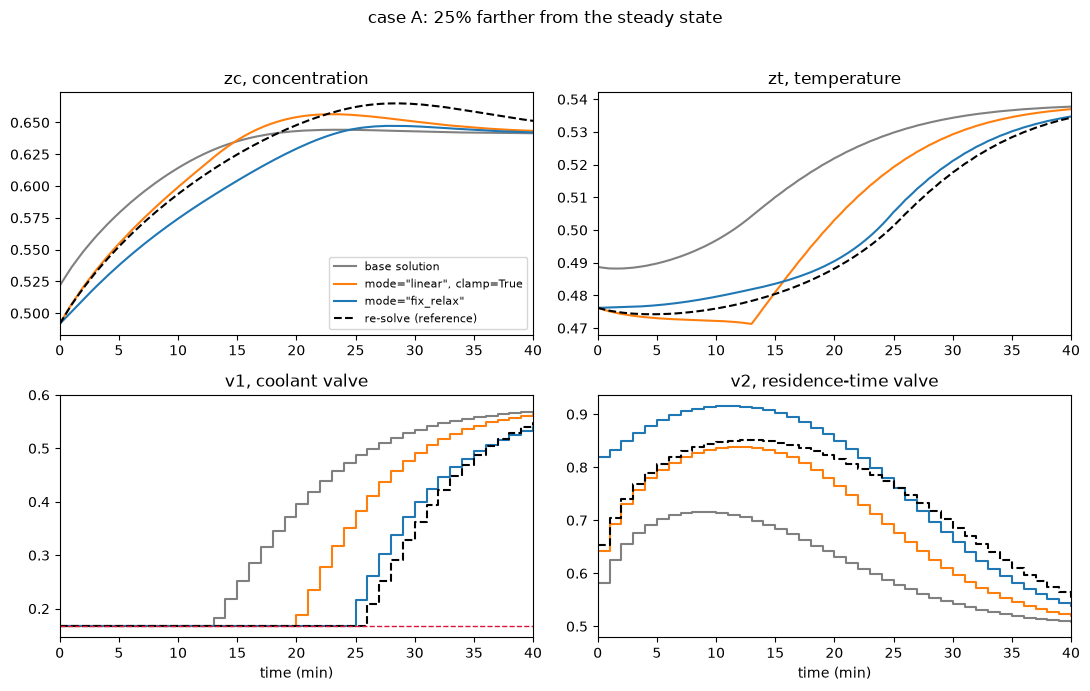

largest error, mode="linear", clamp=True: 1.301
largest error, mode="fix_relax":    0.292


In [6]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    est_fr = estimate(base, perturb_worse, mode="fix_relax")

panels([
    ("base solution", base, None, dict(color="gray")),
    ('mode="linear", clamp=True', base, est_lin, dict(color="tab:orange")),
    ('mode="fix_relax"', base, est_fr, dict(color="tab:blue")),
    ("re-solve (reference)", truth_worse, None,
     dict(color="black", ls="--")),
], title='case A: 25% farther from the steady state')

def worst_err(est, truth_m):
    truth = {v.name: pyo.value(v, exception=False)
             for v in truth_m.component_data_objects(pyo.Var, active=True)}
    w = 0.0
    for vd, val in est.items():
        tv = truth.get(vd.name)
        if tv is None or not vd.name.startswith(("zc[", "zt[", "v1[", "v2[")):
            continue
        w = max(w, abs(val - tv) / max(abs(tv), 1e-2))
    return w

print(f'largest error, mode="linear", clamp=True: '
      f"{worst_err(est_lin, truth_worse):.3f}")
print(f'largest error, mode="fix_relax":    '
      f"{worst_err(est_fr, truth_worse):.3f}")


## 4. What `mode="path"` adds: the record of active-set changes

* predictions: `estimate(mode="fix_relax")` and `estimate(mode="path")`
* reference: re-solve at the measured state

`mode="path"` applies the change a little at a time instead of all at
once, and every time v1 reaches its minimum on some interval or leaves
it, it records the fraction of the change at which that happened.

The first figure is case A, the measured state 25% farther out. The two
predictions are within 4.4e-6 of each other there, so the figure draws
the fix_relax line wider with the path line on top of it, and both
reach 0.292.

The two coincide exactly only when no bound changes status, where both
reduce to the plain step. Once bounds move they compute different
things. `fix_relax` applies a single direction, taken under the active
set it settles on, over the whole change, while `path` applies each
segment's own direction over its own stretch of the change. On this
model those directions stay close enough that the difference never
shows. Over the four measured states the largest gap is the 4.4e-6
here, and at the steady state below it is 4.1e-7.

The record follows, and it is the part no other mode produces. v1
leaves its minimum interval by interval, from minute 12 backward, and
the first change comes after 1.3% of the change to the steady state.
That first fraction is how much measurement discrepancy leaves the held
solve's active set unchanged.


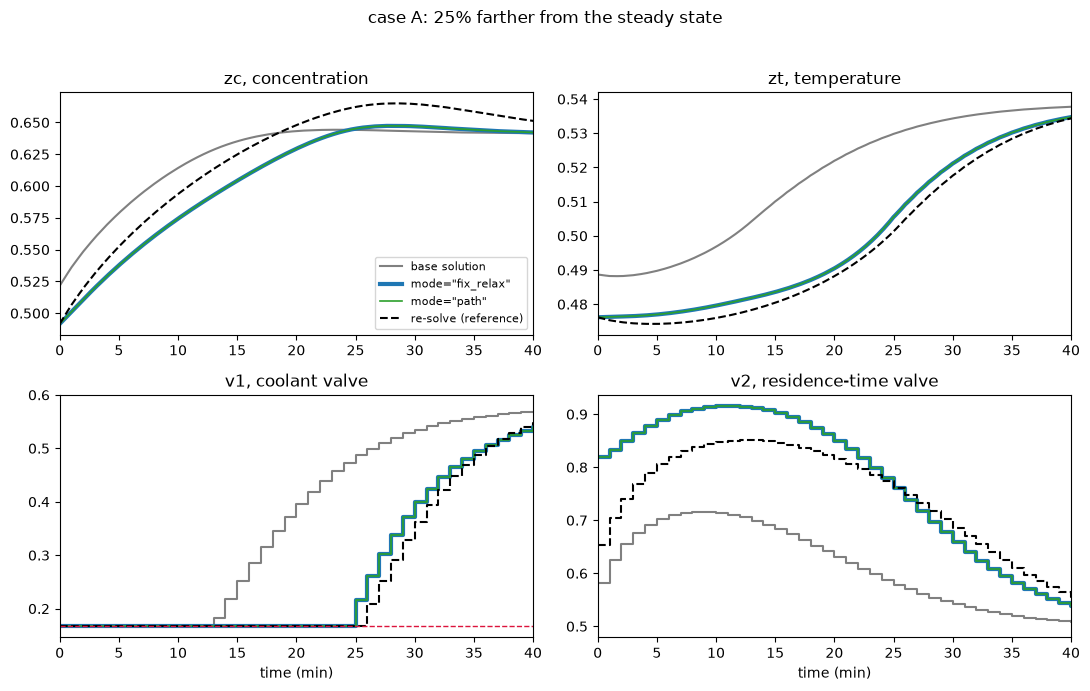

case A, 25% farther out:
  largest error, mode="fix_relax": 0.292
  largest error, mode="path":      0.292

the record, over the full change to the steady state:
interval (min)   fraction of the change at which v1 leaves its minimum
      12                0.013
      11                0.039
      10                0.068
       9                0.099
       8                0.134
       7                0.175
       6                0.221
       5                0.275
       4                0.340
       3                0.419
       2                0.518
       1                0.646
       0                0.819


In [7]:
from pyomo_pounce import active_set_changes

FULL = (ZC_SS, ZT_SS)

# the record, taken over the full change to the steady state
perturb_full = [(base.zc0, FULL[0]), (base.zt0, FULL[1])]
record = active_set_changes(base, perturb_full)

# re-solves along the way (also used below)
fracs = np.array([0.1, 0.25, 0.5, 0.75, 1.0])
sweep_truth = {}
for f in fracs:
    tgt = (BASE[0] + f * (FULL[0] - BASE[0]),
           BASE[1] + f * (FULL[1] - BASE[1]))
    sweep_truth[f] = warm_resolve(*tgt)

# case B, used by section 8, and case C, used by sections 6 and 7
Q = 0.25
QTGT = (BASE[0] + Q * (FULL[0] - BASE[0]), BASE[1] + Q * (FULL[1] - BASE[1]))
truth_q = sweep_truth[Q]
perturb_q = [(base.zc0, QTGT[0]), (base.zt0, QTGT[1])]
HALF = (BASE[0] + 0.06, BASE[1] + 0.025)
truth_half = warm_resolve(*HALF)
perturb_half = [(base.zc0, HALF[0]), (base.zt0, HALF[1])]

# the experiment at case A, where the measured state moves away from
# the steady state and v1 is driven harder against its minimum
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    est_fr_a = estimate(base, perturb_worse, mode="fix_relax")
    est_path_a = estimate(base, perturb_worse, mode="path")

panels([
    ("base solution", base, None, dict(color="gray")),
    ('mode="fix_relax"', base, est_fr_a, dict(color="tab:blue", lw=3)),
    ('mode="path"', base, est_path_a, dict(color="tab:green", lw=1.2)),
    ("re-solve (reference)", truth_worse, None, dict(color="black", ls="--")),
], title='case A: 25% farther from the steady state')

print("case A, 25% farther out:")
print(f"  largest error, mode=\"fix_relax\": "
      f"{worst_err(est_fr_a, truth_worse):.3f}")
print(f"  largest error, mode=\"path\":      "
      f"{worst_err(est_path_a, truth_worse):.3f}")

print("\nthe record, over the full change to the steady state:")
print("interval (min)   fraction of the change at which v1 leaves its minimum")
for c in record:
    assert c.action == "leaves" and c.bound == "lower"
    print(f"      {int(c.var.index()):2d}                {c.fraction:.3f}")


The same comparison at the full change, where all 13 intervals leave
the minimum.

* predictions: all three modes
* reference: re-solve at the measured state

`mode="fix_relax"` decides all 13 releases from the multipliers of a
single step taken at the base point, and `mode="path"` applies each at
the fraction the record names. The two land in the same place here,
0.626 against 0.833 for `mode="linear"`, so the figures draw one line
over the other again. The panels also show what any first-order
prediction looks like at a change this large. Even the two active-set
modes miss parts of the trajectories badly.


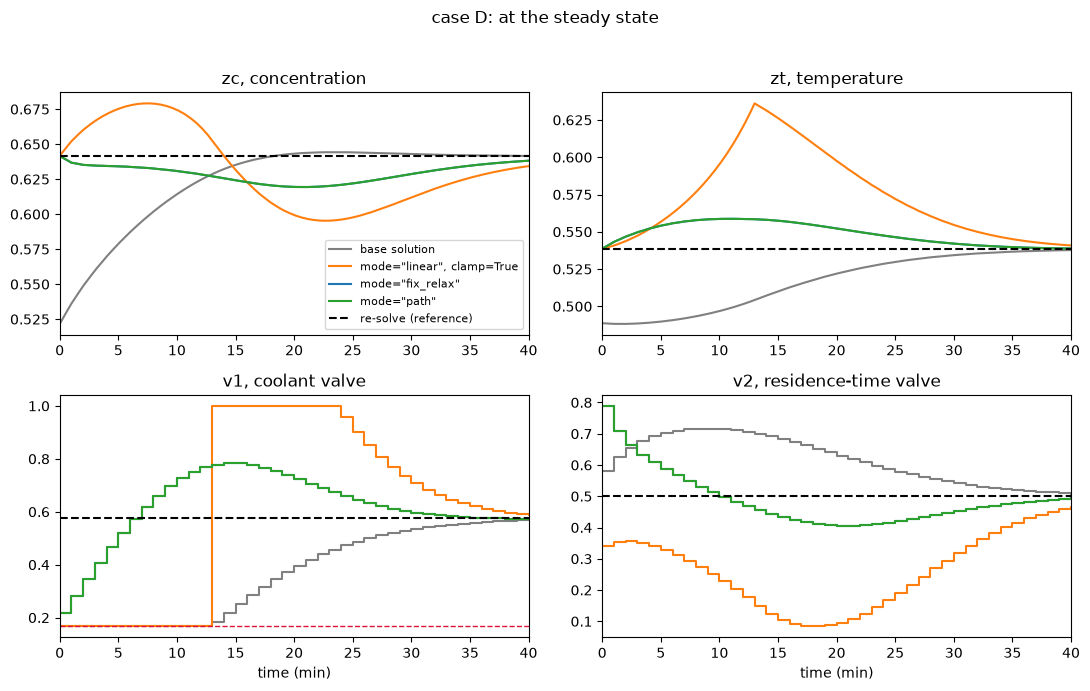

largest error, mode="linear", clamp=True: 0.833
largest error, mode="fix_relax":          0.626
largest error, mode="path":               0.626
mode="path" recorded 13 active-set change(s) here


In [8]:
FULLTGT = sweep_truth[1.0]
perturb_f = [(base.zc0, FULL[0]), (base.zt0, FULL[1])]
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    est_lin_f = estimate(base, perturb_f)
    est_fr_f = estimate(base, perturb_f, mode="fix_relax")
    est_path_f = estimate(base, perturb_f, mode="path")

panels([
    ("base solution", base, None, dict(color="gray")),
    ('mode="linear", clamp=True', base, est_lin_f, dict(color="tab:orange")),
    ('mode="fix_relax"', base, est_fr_f, dict(color="tab:blue")),
    ('mode="path"', base, est_path_f, dict(color="tab:green")),
    ("re-solve (reference)", FULLTGT, None, dict(color="black", ls="--")),
], title='case D: at the steady state')

print(f'largest error, mode="linear", clamp=True: '
      f"{worst_err(est_lin_f, FULLTGT):.3f}")
print(f'largest error, mode="fix_relax":          '
      f"{worst_err(est_fr_f, FULLTGT):.3f}")
print(f'largest error, mode="path":               '
      f"{worst_err(est_path_f, FULLTGT):.3f}")
print(f'mode="path" recorded {len(record)} active-set change(s) here')


## 5. The effect of `predictor_iter` on both modes

`predictor_iter` caps how much work a prediction spends on the active
set. Under `fix_relax` it caps the refinement passes, and under `path`
it caps the recorded changes applied. Both sweeps run at case C,
halfway to the steady state, where seven intervals of v1 leave the
minimum.

* predictions: `estimate(mode=...)` at `predictor_iter` of 1, 2, 4, 8
  and 16, one panel per mode
* reference: re-solve at the measured state
* the last figure puts both modes' wall times on one axis, against the
  re-solve as the dashed line. Times are the best of three repeats on
  this machine.

Both descend 0.763, 0.620, 0.590, 0.495, 0.417 as the cap rises, and
at this measured state they agree to machine precision rather than to
the digits printed, the largest gap over the five caps being 5e-15.
The two are still not the same computation. `fix_relax` applies one
direction over the whole change while `path` applies each segment's own
direction over its own stretch, and the directions stay close enough on
this model that the difference never exceeds 4.4e-6 at any of the four
measured states.

What separates them here is cost. `path` runs the cheaper of the two,
16.8 to 35.9 ms across the caps against 19.3 to 52.0 ms, and both stay
well under the re-solve's 0.41 s.

The panels also show what the cap costs in the trajectories. At a cap
of 1 only the earliest change is applied and the rest of the horizon
carries the base solution's shape. Each doubling matches the re-solve
over more of the horizon, working backward from minute 12, which is
the order the record lists.


re-solve wall time at this measured state: 0.33 s


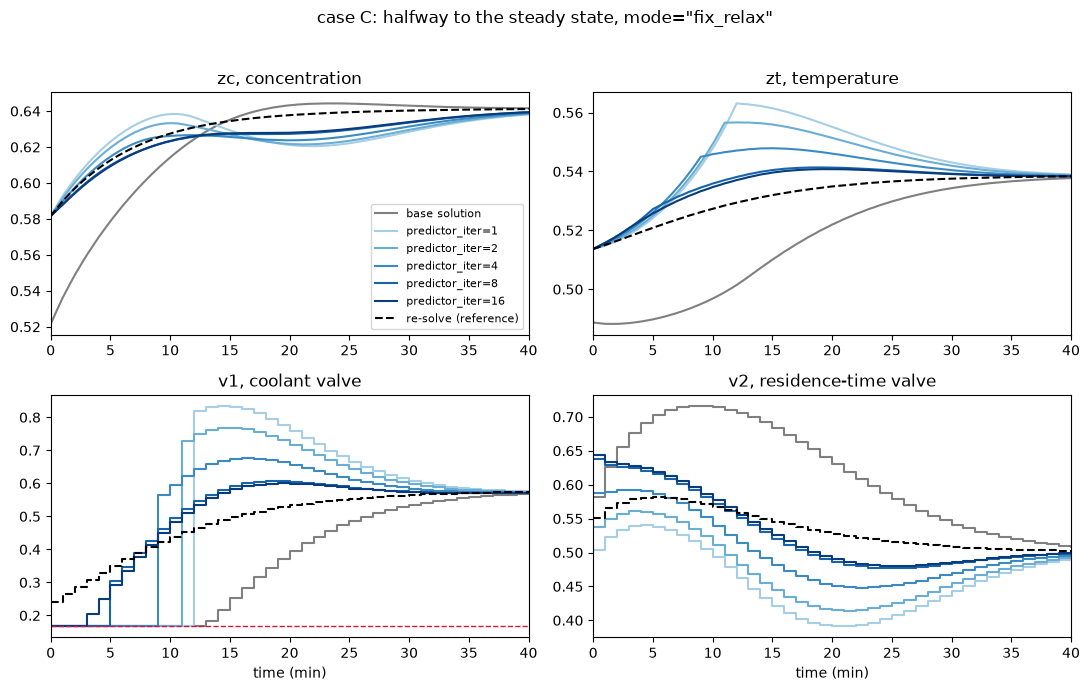

  mode="fix_relax"  predictor_iter= 1   largest error 0.763   wall time    17.6 ms
  mode="fix_relax"  predictor_iter= 2   largest error 0.620   wall time    21.3 ms
  mode="fix_relax"  predictor_iter= 4   largest error 0.590   wall time    30.0 ms
  mode="fix_relax"  predictor_iter= 8   largest error 0.495   wall time    49.6 ms
  mode="fix_relax"  predictor_iter=16   largest error 0.417   wall time    62.1 ms


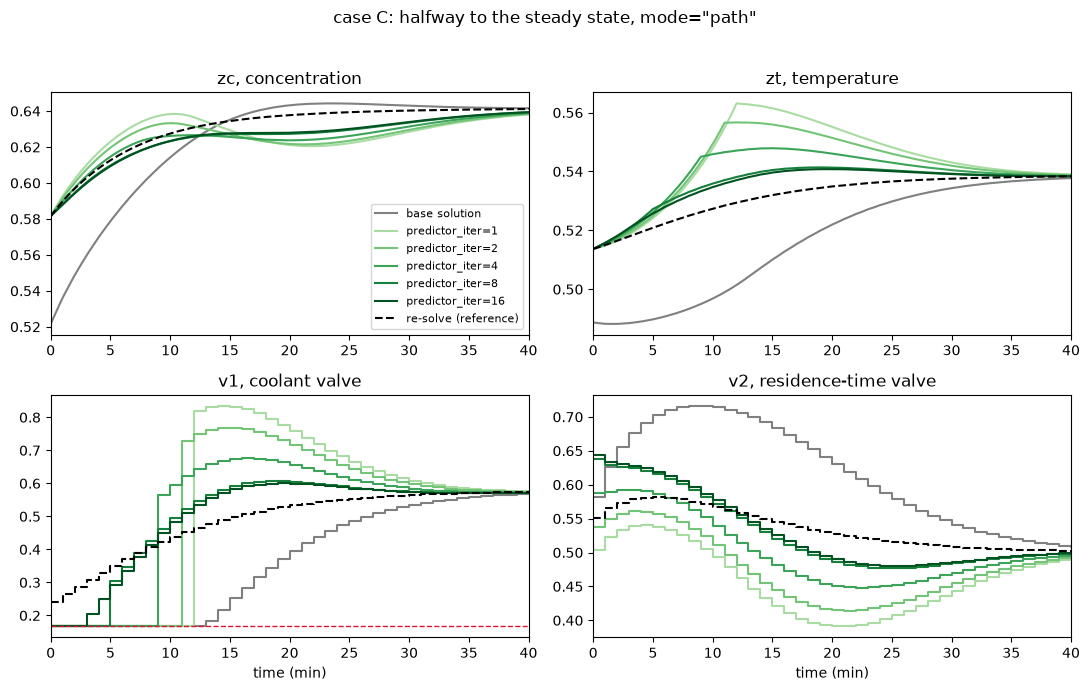

  mode="path"  predictor_iter= 1   largest error 0.763   wall time    16.5 ms
  mode="path"  predictor_iter= 2   largest error 0.620   wall time    16.5 ms
  mode="path"  predictor_iter= 4   largest error 0.590   wall time    21.6 ms
  mode="path"  predictor_iter= 8   largest error 0.495   wall time    30.4 ms
  mode="path"  predictor_iter=16   largest error 0.417   wall time    32.7 ms


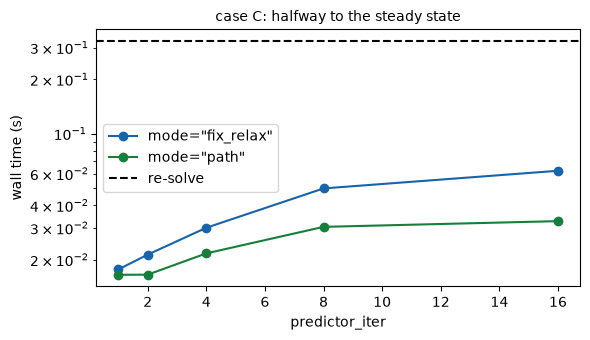

In [9]:
import time as _time

MAXITERS = [1, 2, 4, 8, 16]
GRADS = {"fix_relax": cm.Blues, "path": cm.Greens}


def timed_estimate(mode, perturb, k, reps=3):
    best, est = None, None
    for _ in range(reps):
        t0 = _time.perf_counter()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            est = estimate(base, perturb, mode=mode, predictor_iter=k)
        dt = _time.perf_counter() - t0
        best = dt if best is None else min(best, dt)
    return est, best


def maxiter_figures(perturb, truth, t_resolve, title=None):
    times = {}
    for mode in ("fix_relax", "path"):
        cmap = GRADS[mode]
        ests, times[mode] = {}, {}
        for k in MAXITERS:
            ests[k], times[mode][k] = timed_estimate(mode, perturb, k)
        entries = [("base solution", base, None, dict(color="gray"))]
        for j, k in enumerate(MAXITERS):
            shade = cmap(0.35 + 0.6 * j / (len(MAXITERS) - 1))
            entries.append((f"predictor_iter={k}", base, ests[k],
                            dict(color=shade)))
        entries.append(("re-solve (reference)", truth, None,
                        dict(color="black", ls="--")))
        panels(entries, title=f'{title}, mode="{mode}"')
        for k in MAXITERS:
            print(f'  mode="{mode}"  predictor_iter={k:2d}   largest error '
                  f"{worst_err(ests[k], truth):.3f}   "
                  f"wall time {times[mode][k]*1e3:7.1f} ms")
    plt.figure(figsize=(6, 3.5))
    for mode in ("fix_relax", "path"):
        plt.plot(MAXITERS, [times[mode][k] for k in MAXITERS], "o-",
                 color=GRADS[mode](0.8), label=f'mode="{mode}"')
    plt.axhline(t_resolve, color="black", ls="--", label="re-solve")
    plt.yscale("log")
    plt.xlabel("predictor_iter")
    plt.ylabel("wall time (s)")
    if title is not None:
        plt.title(title, fontsize=10)
    plt.legend()
    plt.tight_layout()
    plt.show()


t0 = _time.perf_counter()
_ = warm_resolve(*HALF)
T_RES_C = _time.perf_counter() - t0
print(f"re-solve wall time at this measured state: {T_RES_C:.2f} s")
maxiter_figures(perturb_half, truth_half, T_RES_C,
                title="case C: halfway to the steady state")


## 6. What `corrector_iter` adds

Every mode so far returns a step, a prediction of where the solution
moves built from the factorization the solve left behind. That step
leaves a residual in the barrier KKT system at the measured state, and
Newton iterations against the same factorization drive that residual
down. Each one costs a back-solve, not a factorization.

`corrector_iter` sets how many to run. It stops early when one fails to
improve the residual, so the number is a budget rather than a count.

The correction reaches past a breakpoint because the predictor has
already worked out which bounds moved, and it applies that once before
iterating. A bound the step takes off its minimum comes out of the
operator, its multiplier held at zero and its complementarity row gone.
A bound the step brings onto its minimum has its diagonal raised to the
stiffness the barrier would assign there. Every other row keeps the
base point's term. Both directions are the same change to one diagonal,
so a single factorization serves the whole correction and every
iteration after it is a back-solve.

That is why the modes start from different places below. `fix_relax`
and `path` decide an active set and hand it over, seven changes at the
case below. `mode="linear"` holds the active set fixed as it builds the
step, so all the correction has to work with is what the clamp left on
a bound, one change at that same case. The record in section 4 puts the
first bound change at fraction 0.0132 of the change to the steady
state, and below that fraction all three modes are the same step.

How far the correction reaches is set by how many crossings the
predictor hands over rather than by the size of the change. It
converges while that number is a few. At a 2% change, one crossing, the
largest relative error goes from 2.4e-3 to 1e-6. At 5% and two
crossings it goes from 1.4e-2 to 2e-6, and at 10% and four crossings
from 6.0e-2 to 6.0e-5.

It aims at the barrier solution at the `mu` the solve finished on
rather than at a re-solve, so its accuracy floors out at that offset,
and it does not set the multipliers, which arrive extrapolated over the
whole perturbation. Once the crossings outnumber what it converges on,
those multipliers are the larger error, which is why the gains in the
sweep below are small.


In [10]:
CORRS = [0, 1, 2, 4, 8]
MODES = ["linear", "fix_relax", "path"]
MODE_GRADS = {"linear": cm.Oranges, "fix_relax": cm.Blues,
              "path": cm.Greens}


def timed_corrected(mode, perturb, k, reps=3):
    # estimate() at a corrector budget, timed the way section 6 times
    # the predictor_iter sweep
    best, est = None, None
    for _ in range(reps):
        t0 = _time.perf_counter()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            est = estimate(base, perturb, mode=mode, corrector_iter=k)
        dt = _time.perf_counter() - t0
        best = dt if best is None else min(best, dt)
    return est, best


t0 = _time.perf_counter()
_ = warm_resolve(*QTGT)
T_RES_B = _time.perf_counter() - t0
print(f"re-solve wall time at case B: {T_RES_B:.2f} s")


def case_sweep(perturb, truth, t_resolve, label):
    # one four-variable panel per mode, then the wall times together
    times = {}
    for mode in MODES:
        cmap = MODE_GRADS[mode]
        ests, times[mode] = {}, {}
        for k in CORRS:
            ests[k], times[mode][k] = timed_corrected(mode, perturb, k)
        entries = [("base solution", base, None, dict(color="gray"))]
        for j, k in enumerate(CORRS):
            shade = cmap(0.35 + 0.6 * j / (len(CORRS) - 1))
            entries.append((f"corrector_iter={k}", base, ests[k],
                            dict(color=shade)))
        entries.append(("re-solve (reference)", truth, None,
                        dict(color="black", ls="--")))
        panels(entries, title=f'{label}, mode="{mode}"')
        errs = "   ".join(
            f"{k}: {worst_err(ests[k], truth):.6f}" for k in CORRS)
        print(f'  mode="{mode}"  largest error by corrector_iter   {errs}')
    plt.figure(figsize=(6, 3.5))
    for mode in MODES:
        plt.plot(CORRS, [times[mode][k] for k in CORRS], "o-",
                 color=MODE_GRADS[mode](0.8), label=f'mode="{mode}"')
    plt.axhline(t_resolve, color="black", ls="--", label="re-solve")
    plt.yscale("log")
    plt.xlabel("corrector_iter")
    plt.ylabel("wall time (s)")
    plt.title(label, fontsize=10)
    plt.legend()
    plt.tight_layout()
    plt.show()


re-solve wall time at case B: 0.26 s


### The sweep at case B

The sweep runs at case B, a quarter of the way to the steady state,
where seven intervals of v1 leave the minimum.

All three modes improve by about five percent and stop. The two
active-set modes go from 0.199 to 0.189 and `mode="linear"` from 0.564
to 0.538, so what separates them here is where each one starts rather
than what the correction did for it. The predictor passes its active
set to the correction once, before the iterations begin, and seven
crossings is more than that one pass accounts for.


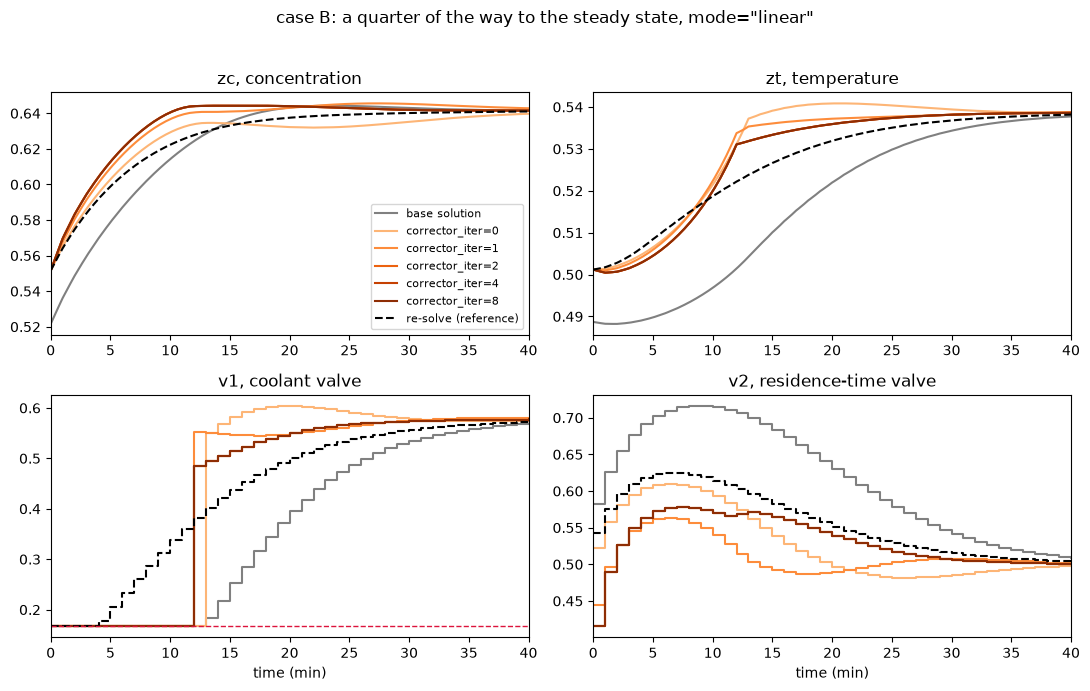

  mode="linear"  largest error by corrector_iter   0: 0.563714   1: 0.537605   2: 0.537605   4: 0.537605   8: 0.537605


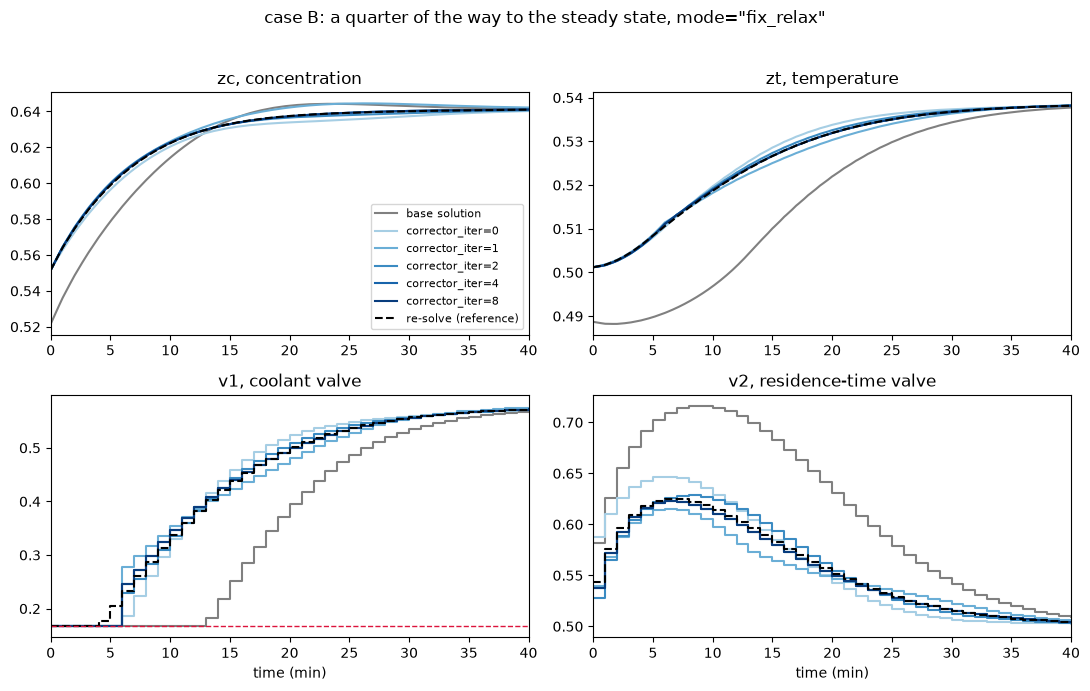

  mode="fix_relax"  largest error by corrector_iter   0: 0.199466   1: 0.189235   2: 0.189235   4: 0.189235   8: 0.189235


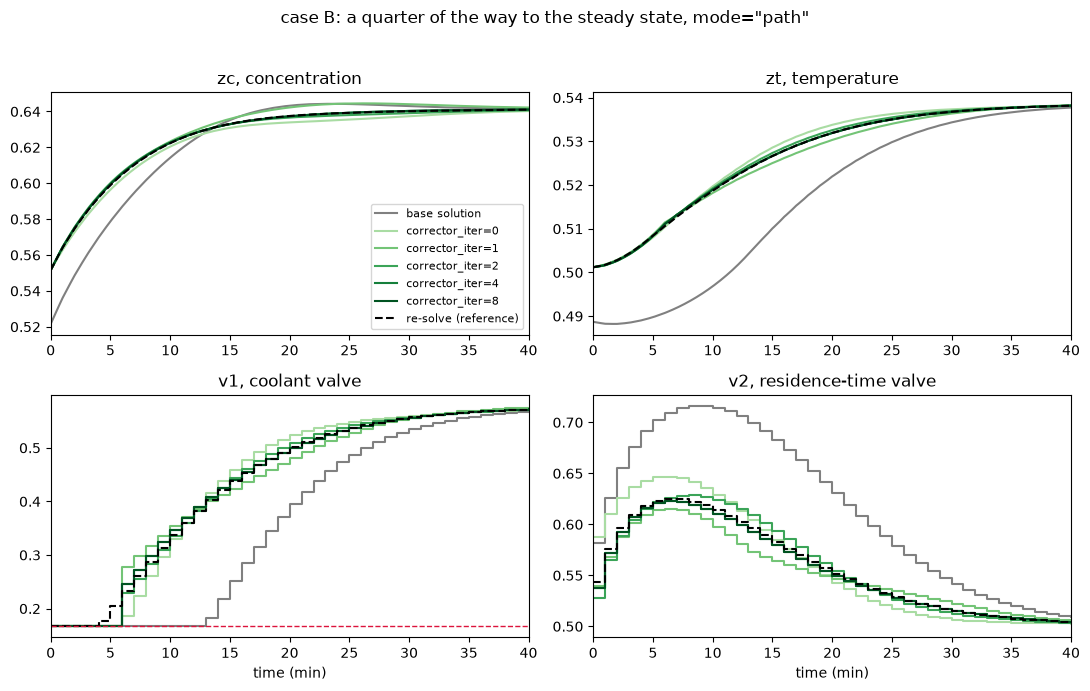

  mode="path"  largest error by corrector_iter   0: 0.199466   1: 0.189235   2: 0.189235   4: 0.189235   8: 0.189235


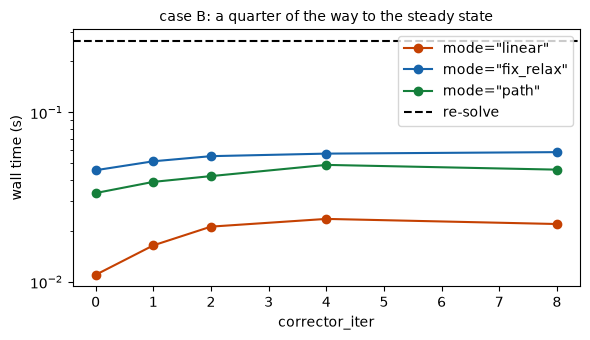

In [11]:
case_sweep(perturb_q, truth_q, T_RES_B,
           "case B: a quarter of the way to the steady state")


## 7. A held solve at the record's first breakpoint: `degeneracy`

The record in section 4 names the state where v1's interval 12 leaves
its minimum, 1.3% of the way from the upset to the steady state. This
section holds a solve at that state. Interval 12 sits on its
minimum with a multiplier of the same order as the slack, the activity
classifier declines to call the bound active or inactive, and
`gradient()` warns that its value is one-sided. The solution has a
kink there. Toward the steady state the bound releases, away from it
the bound holds, and no single linear step is right for both sides.

* held solve: (0.5232, 0.4894), the record's first breakpoint
* measured state: (0.5256, 0.4904), 2% of the full change further
  toward the steady state
* predictions: all three modes, under `degeneracy="one_sided"` in the
  left column and `degeneracy="directional"` in the right
* reference: re-solve at the measured state

`degeneracy` selects what happens at such a base point. `"one_sided"`
takes the single-sided value the complementarity split produces
(active when the multiplier exceeds the slack). Here the split
classifies the bound as
inactive, so `mode="path"` cannot release it and degrades to the
linear step. Its largest error is 0.0077 and its record is
empty. Linear
and path are identical in the left column, so the figure draws the
linear line widest with the path line on top. `mode="fix_relax"`
reaches 0.0018, but not by construction. Its release test reads a
sign from the uncorrected step at a point where the true multiplier
is exactly zero, and on this model that sign happens to be right.

`"directional"` (the default) decides the bound for the
perturbation's own direction by the directional derivative QP (the
sIPOPT paper's eq. 14) on the held factorization. All three modes
land at 0.0018. For fix_relax that is the same number as before, but
the release decision now comes from the QP instead of the sign, so
what happened to be right is now right by construction. The record says
v1[12] leaves its minimum at fraction 0.008, the zero crossing of
the residual multiplier the solve left.

At a step this small the curves coincide at full scale, so the figure
shows v1 alone, zoomed to the intervals around the kink, and the
printed table carries the comparison over all variables.


In [12]:
from pyomo_pounce import estimate_report, gradient

F1 = record[0].fraction
E = (BASE[0] + F1 * (FULL[0] - BASE[0]), BASE[1] + F1 * (FULL[1] - BASE[1]))
ETGT = (E[0] + 0.02 * (FULL[0] - BASE[0]), E[1] + 0.02 * (FULL[1] - BASE[1]))
held_e = warm_resolve(*E)
perturb_e = [(held_e.zc0, ETGT[0]), (held_e.zt0, ETGT[1])]
event_variable = record[0].var.name
held_event_variable = held_e.find_component(event_variable)

print(f"the record's first entry: {record[0].var.name} leaves its "
      f"{record[0].bound} bound at fraction {F1:.4f}")
print(f"classifier at this held solve: {event_variable} is "
      f"{estimate_report(held_e, perturb_e).activity[event_variable]}")
# The warning below is gradient()'s. With no direction to choose a
# side, it names the degenerate bound and refers the caller to
# estimate().
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    g12 = gradient(held_event_variable, wrt=held_e.zc0)
for item in caught:
    print(f"{item.category.__name__}: {item.message}")
print(f"gradient({event_variable}, wrt=zc0) = {g12:.4f}, one side's value")


the record's first entry: v1[12.0] leaves its lower bound at fraction 0.0132
classifier at this held solve: v1[12.0] is ambiguous
gradient(v1[12.0], wrt=zc0) = 2.8473, one side's value


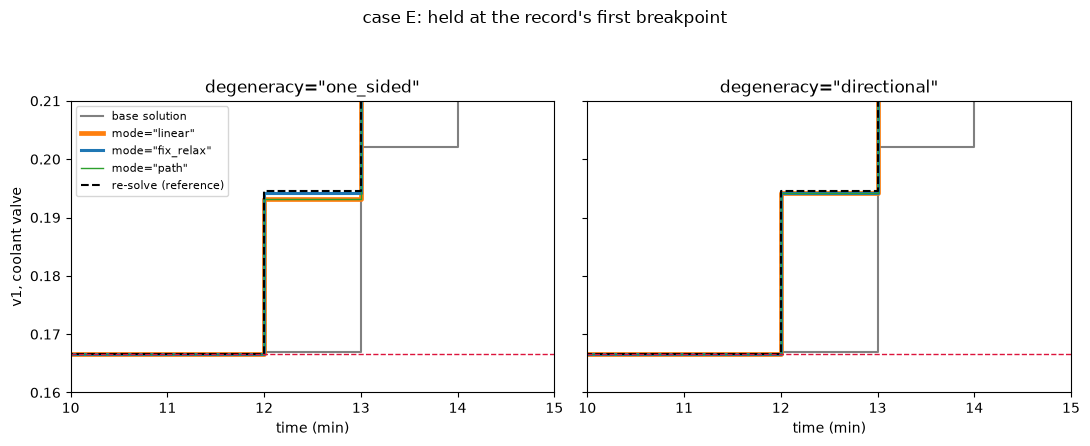

degeneracy="one_sided", mode="linear":  largest error 0.0077
degeneracy="one_sided", mode="fix_relax":  largest error 0.0018
degeneracy="one_sided", mode="path":  largest error 0.0077
degeneracy="directional", mode="linear":  largest error 0.0018
degeneracy="directional", mode="fix_relax":  largest error 0.0018
degeneracy="directional", mode="path":  largest error 0.0018
record under "one_sided": empty
record under "directional": [('v1[12.0]', 'lower', 'leaves', 0.008)]


In [13]:
truth_e = warm_resolve(*ETGT)
ests = {}
for deg in ("one_sided", "directional"):
    for mode in ("linear", "fix_relax", "path"):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            ests[deg, mode] = estimate(held_e, perturb_e, mode=mode,
                                       degeneracy=deg)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
t_truth, v1_truth = v1_profile(truth_e)
for ax, deg in zip(axes, ("one_sided", "directional")):
    series = [
        ("base solution", held_e, None, dict(color="gray")),
        ('mode="linear"', held_e, ests[deg, "linear"],
         dict(color="tab:orange", lw=3.4)),
        ('mode="fix_relax"', held_e, ests[deg, "fix_relax"],
         dict(color="tab:blue", lw=2.2)),
        ('mode="path"', held_e, ests[deg, "path"],
         dict(color="tab:green", lw=1.0)),
    ]
    for label, mm, e, kw in series:
        t_, v_ = v1_profile(mm, e)
        ax.step(t_, v_, where="post", label=label, **kw)
    ax.step(t_truth, v1_truth, where="post", color="black", ls="--",
            label="re-solve (reference)")
    ax.axhline(V1_MIN, color="crimson", lw=1, ls="--")
    ax.set_xlim(10, 15)
    ax.set_ylim(0.160, 0.210)
    ax.set_title(f'degeneracy="{deg}"')
    ax.set_xlabel("time (min)")
axes[0].set_ylabel("v1, coolant valve")
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("case E: held at the record's first breakpoint")
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

for deg in ("one_sided", "directional"):
    for mode in ("linear", "fix_relax", "path"):
        print(f'degeneracy="{deg}", mode="{mode}":  largest error '
              f"{worst_err(ests[deg, mode], truth_e):.4f}")
for deg in ("one_sided", "directional"):
    ch = active_set_changes(held_e, perturb_e, degeneracy=deg)
    shown = ([(c.var.name, c.bound, c.action, round(c.fraction, 3))
              for c in ch] or "empty")
    print(f'record under "{deg}": {shown}')


## 8. Close the loop: active-set-aware advanced-step NMPC

The open-loop experiments above answer one measurement update at a time. A controller
has to repeat the complete cycle: predict, solve the next horizon in the background,
measure, correct from the held KKT factor, validate the full corrected point, apply the
first move, propagate an independent plant, shift, and prepare the next solve.

The reusable, tested driver in `pounce.examples.asnmpc_cstr` implements that ordering.
The plant is integrated separately with RK4 and carries disturbances and model mismatch
that the controller does not see. Six policies receive exactly the same seeded
measurements:

- a fresh nonlinear-programming solve after every measurement;
- the stale prediction with no correction;
- clamped linear sensitivity, fix-relax, and active-set path updates; and
- the path update behind a full-point guard and fresh-solve fallback.

The questions are deliberately practical: which policy follows the full solve, when does
the active set change, and when should a cheap update be rejected rather than trusted?


In [14]:
from dataclasses import asdict

from IPython.display import Markdown, display

from pounce.examples.asnmpc_cstr import (
    directional_degeneracy_experiment,
    run_campaigns,
)
closed_loop_config = CstrConfig(
    horizon_intervals=100,
    sample_time_min=1.0,
    collocation_points=3,
    temperature_limit=0.55,
    deadline_s=0.100,
)
closed_loop_results = run_campaigns(
    closed_loop_config, steps=30, seed=19, warmup=True, repository=repo_root
)
len(closed_loop_results)


18

### 8.1 Quality and online work

The paper-scale controller retains the original 100 one-minute intervals and runs 30
closed-loop samples in each of three campaigns. The first table asks whether each policy
actually controls the independent plant; the second separates online update time from the
background solve that advanced-step NMPC moves off the critical path. The online timing
includes the applied estimate and a separate diagnostic-report replay because the current
public API computes their predictor/corrector work independently. It excludes the third
replay used to build the event ledger; an end-to-end guard that uses the path-budget check
must add that ledger cost unless the applied update exposes its own record.

A full re-solve has no background phase, so all of its solve time is online. The 100 ms
deadline is illustrative, not a deployment claim. The final row stamps the source, model,
tolerance, machine, Python version, and warm-up policy beside the measurements.


In [15]:
summary = [result.summary() for result in closed_loop_results]
for row in summary:
    for source, target in (
        ("update_latency_median_s", "update_median_ms"),
        ("update_latency_p95_s", "update_p95_ms"),
        ("full_solve_latency_median_s", "full_solve_median_ms"),
        ("background_latency_median_s", "background_median_ms"),
    ):
        row[target] = None if row[source] is None else 1000.0 * row[source]

def markdown_table(rows, columns):
    def cell(value):
        if value is None:
            return "—"
        return f"{value:.5g}" if isinstance(value, float) else str(value)
    labels = [label for _, label in columns]
    lines = [
        "| " + " | ".join(labels) + " |",
        "| " + " | ".join("---" for _ in labels) + " |",
    ]
    lines.extend(
        "| " + " | ".join(cell(row[key]) for key, _ in columns) + " |"
        for row in rows
    )
    return Markdown("\n".join(lines))

ordered_summary = sorted(summary, key=lambda row: (row["campaign"], row["policy"]))
quality_columns = [
    ("campaign", "campaign"), ("policy", "policy"),
    ("iae", "IAE"), ("ise", "ISE"),
    ("economic_stage_cost", "stage cost"),
    ("total_control_movement", "control movement"),
    ("maximum_temperature_violation", "max T violation"),
]
switching_columns = [
    ("campaign", "campaign"), ("policy", "policy"),
    ("active_set_changes", "set changes"),
    ("fallback_full_solves", "fallbacks"),
    ("fallback_fraction", "fallback rate"),
    ("solver_failures", "failures"),
    ("solver_recoveries", "recoveries"),
]
latency_columns = [
    ("campaign", "campaign"), ("policy", "policy"),
    ("update_median_ms", "online median (ms)"),
    ("update_p95_ms", "online p95 (ms)"),
    ("full_solve_median_ms", "full solve (ms)"),
    ("background_median_ms", "background (ms)"),
    ("deadline_misses", "deadline misses"),
]
display(Markdown("**Closed-loop quality**"))
display(markdown_table(ordered_summary, quality_columns))
display(Markdown("**Active sets and fallback behavior**"))
display(markdown_table(ordered_summary, switching_columns))
display(Markdown("**Online and background timing**"))
display(markdown_table(ordered_summary, latency_columns))

stamp = closed_loop_results[0].stamp
stamp_row = asdict(stamp)
stamp_columns = [(key, key.replace("_", " ")) for key in stamp_row]
display(Markdown("**Benchmark provenance**"))
display(markdown_table([stamp_row], stamp_columns))


**Closed-loop quality**

| campaign | policy | IAE | ISE | stage cost | control movement | max T violation |
| --- | --- | --- | --- | --- | --- | --- |
| constraint_switching | clamped_linear | 1.4131 | 0.072392 | 3.1433 | 1.7563 | 0 |
| constraint_switching | fix_relax | 1.4091 | 0.072361 | 3.1455 | 1.7722 | 0 |
| constraint_switching | full_resolve | 1.4091 | 0.072361 | 3.1455 | 1.7722 | 0 |
| constraint_switching | guarded_path | 1.4091 | 0.072361 | 3.1455 | 1.7722 | 0 |
| constraint_switching | no_correction | 10.621 | 4.752 | 35.817 | 1.158 | 0.54092 |
| constraint_switching | path | 1.4091 | 0.072361 | 3.1455 | 1.7722 | 0 |
| nominal | clamped_linear | 1.5567 | 0.077175 | 3.8757 | 1.1564 | 0 |
| nominal | fix_relax | 1.5567 | 0.077175 | 3.8757 | 1.1564 | 0 |
| nominal | full_resolve | 1.5567 | 0.077175 | 3.8757 | 1.1564 | 0 |
| nominal | guarded_path | 1.5567 | 0.077175 | 3.8757 | 1.1564 | 0 |
| nominal | no_correction | 1.5567 | 0.077181 | 3.8757 | 1.158 | 0 |
| nominal | path | 1.5567 | 0.077175 | 3.8757 | 1.1564 | 0 |
| stress_model_mismatch | clamped_linear | 2.3707 | 0.12535 | 3.2892 | 1.4859 | 0 |
| stress_model_mismatch | fix_relax | 2.3796 | 0.1267 | 3.323 | 1.6473 | 0 |
| stress_model_mismatch | full_resolve | 2.3331 | 0.12152 | 3.2142 | 1.1411 | 0 |
| stress_model_mismatch | guarded_path | 2.3331 | 0.12152 | 3.2142 | 1.1411 | 0 |
| stress_model_mismatch | no_correction | 13.254 | 6.3068 | 46.579 | 1.158 | 0.55844 |
| stress_model_mismatch | path | 2.3796 | 0.1267 | 3.323 | 1.6473 | 0 |

**Active sets and fallback behavior**

| campaign | policy | set changes | fallbacks | fallback rate | failures | recoveries |
| --- | --- | --- | --- | --- | --- | --- |
| constraint_switching | clamped_linear | 0 | 0 | 0 | 0 | 0 |
| constraint_switching | fix_relax | 0 | 0 | 0 | 0 | 0 |
| constraint_switching | full_resolve | 0 | 0 | 0 | 0 | 0 |
| constraint_switching | guarded_path | 1 | 0 | 0 | 0 | 0 |
| constraint_switching | no_correction | 0 | 0 | 0 | 0 | 0 |
| constraint_switching | path | 1 | 0 | 0 | 0 | 0 |
| nominal | clamped_linear | 0 | 0 | 0 | 0 | 0 |
| nominal | fix_relax | 0 | 0 | 0 | 0 | 0 |
| nominal | full_resolve | 0 | 0 | 0 | 0 | 0 |
| nominal | guarded_path | 0 | 0 | 0 | 0 | 0 |
| nominal | no_correction | 0 | 0 | 0 | 0 | 0 |
| nominal | path | 0 | 0 | 0 | 0 | 0 |
| stress_model_mismatch | clamped_linear | 0 | 0 | 0 | 0 | 0 |
| stress_model_mismatch | fix_relax | 0 | 0 | 0 | 0 | 0 |
| stress_model_mismatch | full_resolve | 0 | 0 | 0 | 0 | 0 |
| stress_model_mismatch | guarded_path | 11 | 1 | 0.033333 | 0 | 0 |
| stress_model_mismatch | no_correction | 0 | 0 | 0 | 0 | 0 |
| stress_model_mismatch | path | 11 | 0 | 0 | 0 | 0 |

**Online and background timing**

| campaign | policy | online median (ms) | online p95 (ms) | full solve (ms) | background (ms) | deadline misses |
| --- | --- | --- | --- | --- | --- | --- |
| constraint_switching | clamped_linear | 19.473 | 35.226 | — | 263.07 | 0 |
| constraint_switching | fix_relax | 80.622 | 98.903 | — | 263.93 | 2 |
| constraint_switching | full_resolve | 261.28 | 619.27 | 261.28 | — | 30 |
| constraint_switching | guarded_path | 72.242 | 83.072 | — | 262.79 | 0 |
| constraint_switching | no_correction | 0 | 0 | — | 261.08 | 0 |
| constraint_switching | path | 69.488 | 83.019 | — | 264.28 | 0 |
| nominal | clamped_linear | 17.929 | 35.879 | — | 266.25 | 0 |
| nominal | fix_relax | 68.436 | 83.524 | — | 259.84 | 0 |
| nominal | full_resolve | 264.23 | 575.83 | 264.23 | — | 30 |
| nominal | guarded_path | 66.375 | 78.419 | — | 260.9 | 0 |
| nominal | no_correction | 0 | 0 | — | 260.12 | 0 |
| nominal | path | 64.55 | 77.392 | — | 261.95 | 0 |
| stress_model_mismatch | clamped_linear | 33.97 | 36.747 | — | 263.14 | 0 |
| stress_model_mismatch | fix_relax | 87.27 | 95.209 | — | 265.84 | 1 |
| stress_model_mismatch | full_resolve | 263.13 | 599.99 | 263.13 | — | 30 |
| stress_model_mismatch | guarded_path | 75.146 | 84.678 | 282.66 | 265.11 | 1 |
| stress_model_mismatch | no_correction | 0 | 0 | — | 260.91 | 0 |
| stress_model_mismatch | path | 76.079 | 87.022 | — | 265.45 | 1 |

**Benchmark provenance**

| pounce commit | model revision | solver tolerance | platform | python | warmup excluded |
| --- | --- | --- | --- | --- | --- |
| 496bc28cbe32dbad986211af2bfaf9448be97f96 | hicks-ray-collocation-asnmpc-v1 | 1e-08 | Linux-6.6.114.1-microsoft-standard-WSL2-x86_64-with-glibc2.39 | 3.13.5 | True |

The nominal campaign is the sanity check: every corrected policy reproduces the fresh
solve's closed-loop quality, while its factorization work stays in the background. The
constraint-switching campaign is the useful separation: leaving the prediction stale
violates the temperature limit, while fix-relax and path updates track the fresh solve.
The stress campaign's initial concentration bias is 4.5 times the configured local trust
scale, so it deliberately forces an out-of-validity fallback rather than testing subtle
model-mismatch detection. After that reset, the guard can accept later corrected points.

### 8.2 What the guard accepts—and what it cannot prove

The guarded policy accepts only a corrected point whose scaled measurement displacement
is inside the trust region, the corrector's full-point feasibility is small,
stationarity and complementarity are below their limits, the corrector made progress, the
path budget was not exhausted, the predicted temperature is safe, and manipulated-variable
activity is not ambiguous. A rejection performs a fresh solve at the measurement and resets
both the warm start and held factorization.

The black crosses below mark guarded rejections. They are evidence that the decision is
visible, not that it is optimal. Measurements are capped at the controller model's
temperature bound because its initial state is pinned there; this example guard does not
replace plant interlocks, robust constraint tightening, a state estimator, or a
deadline-aware scheduler. A fallback
may miss the illustrative deadline; that miss is reported rather than hidden.


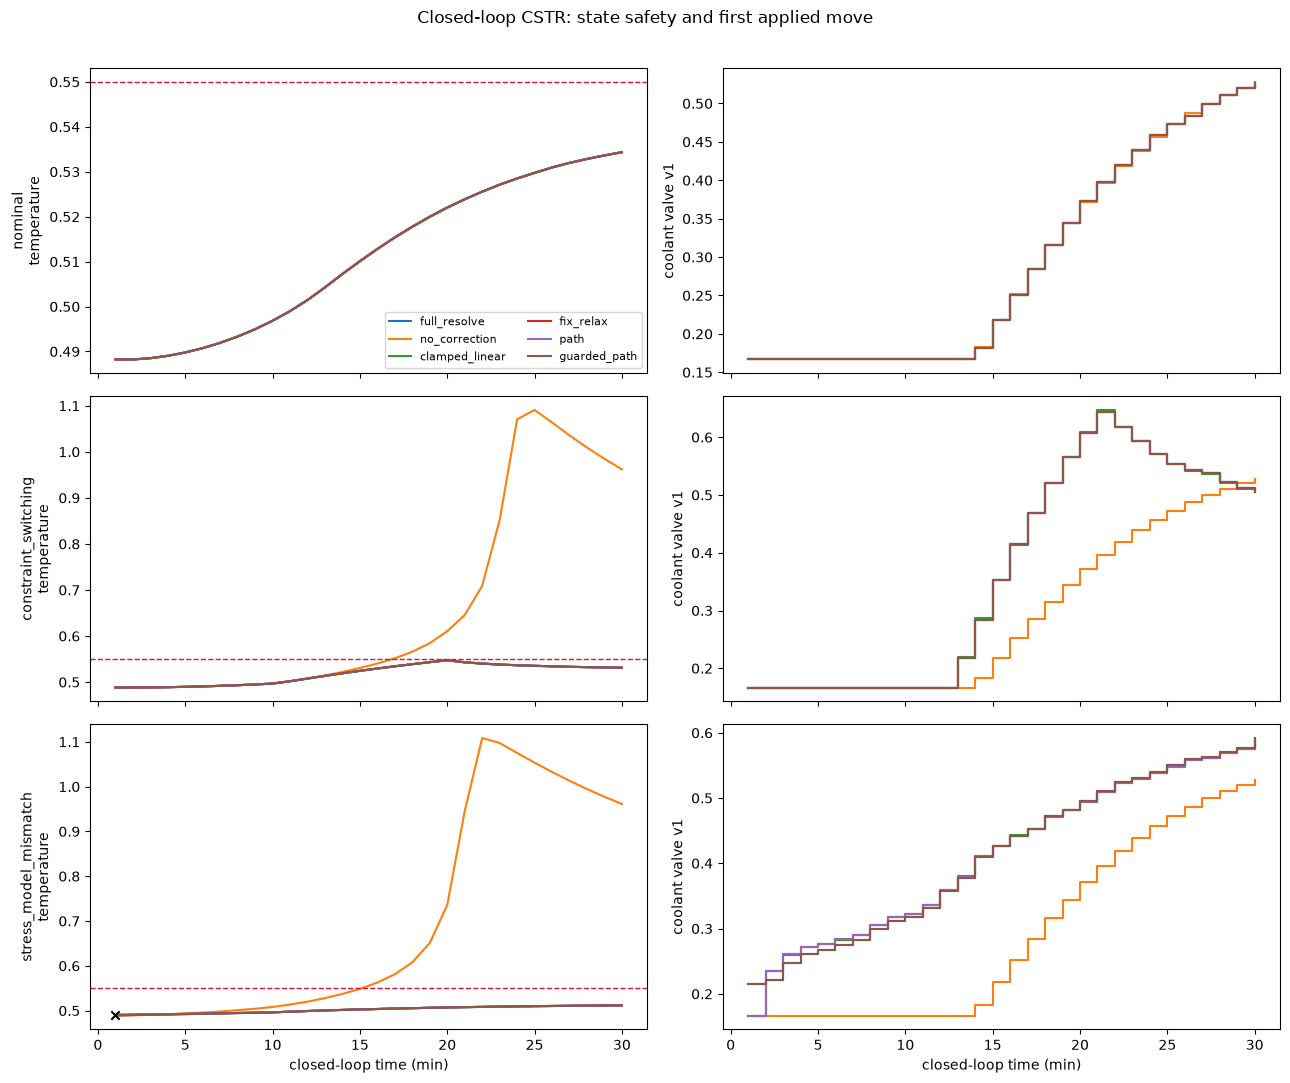

In [16]:
campaign_names = ["nominal", "constraint_switching", "stress_model_mismatch"]
policy_order = [
    "full_resolve", "no_correction", "clamped_linear",
    "fix_relax", "path", "guarded_path",
]
lookup = {(r.campaign, r.policy): r for r in closed_loop_results}
fig, axes = plt.subplots(3, 2, figsize=(13, 11), sharex=True)
for row, campaign_name in enumerate(campaign_names):
    for policy in policy_order:
        result = lookup[campaign_name, policy]
        time_min = closed_loop_config.sample_time_min * np.arange(1, len(result.samples) + 1)
        temperature = [sample.plant_state_after[1] for sample in result.samples]
        coolant = [sample.applied_control[0] for sample in result.samples]
        axes[row, 0].plot(time_min, temperature, label=policy)
        axes[row, 1].step(time_min, coolant, where="post", label=policy)
        if policy == "guarded_path":
            rejected = [sample.sample + 1 for sample in result.samples if not sample.diagnostics.accepted]
            if rejected:
                rejected_t = closed_loop_config.sample_time_min * np.asarray(rejected)
                rejected_y = [temperature[index - 1] for index in rejected]
                axes[row, 0].scatter(rejected_t, rejected_y, marker="x", color="black", zorder=5)
    axes[row, 0].axhline(closed_loop_config.temperature_limit, color="crimson", ls="--", lw=1)
    axes[row, 0].set_ylabel(f"{campaign_name}\ntemperature")
    axes[row, 1].set_ylabel("coolant valve v1")
axes[-1, 0].set_xlabel("closed-loop time (min)")
axes[-1, 1].set_xlabel("closed-loop time (min)")
axes[0, 0].legend(ncol=2, fontsize=8)
fig.suptitle("Closed-loop CSTR: state safety and first applied move")
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


### 8.2 What changed, and when

A full row for every state, control, and fallback obscures the events. The first ledger
below shows only samples where the active-set path changes; the second summarizes guarded
fallbacks by campaign. The complete machine-readable rows remain in `timeline_rows` for
downstream inspection. Sample indices are zero-based, matching `ClosedLoopResult.samples`.


In [17]:
timeline_rows = []
for result in closed_loop_results:
    if result.policy not in ("path", "guarded_path"):
        continue
    for row in result.event_timeline():
        if row["path_length"] or row["full_resolve"]:
            timeline_rows.append({"campaign": result.campaign, "policy": result.policy, **row})

transition_rows = [
    {
        "campaign": row["campaign"],
        "policy": row["policy"],
        "sample": row["sample"],
        "changes": "; ".join(row["active_set_changes"]),
        "accepted": row["accepted"],
        "fallback": row["full_resolve"],
    }
    for row in timeline_rows if row["path_length"]
]
fallback_rows = []
for campaign_name in campaign_names:
    result = lookup[campaign_name, "guarded_path"]
    rejected = [sample for sample in result.samples if not sample.diagnostics.accepted]
    reasons = sorted({reason for sample in rejected for reason in sample.diagnostics.reasons})
    fallback_rows.append({
        "campaign": campaign_name,
        "fallbacks": len(rejected),
        "rate": result.metrics.fallback_fraction,
        "first": rejected[0].sample if rejected else None,
        "last": rejected[-1].sample if rejected else None,
        "reasons": ", ".join(reasons) if reasons else "—",
    })

display(Markdown("**Active-set transitions**"))
display(markdown_table(transition_rows, [
    ("campaign", "campaign"), ("policy", "policy"),
    ("sample", "sample"), ("changes", "path changes"),
    ("accepted", "accepted"), ("fallback", "fallback"),
]))
display(Markdown("**Guarded fallback summary**"))
display(markdown_table(fallback_rows, [
    ("campaign", "campaign"), ("fallbacks", "fallbacks"),
    ("rate", "rate"), ("first", "first sample"),
    ("last", "last sample"), ("reasons", "observed reasons"),
]))


**Active-set transitions**

| campaign | policy | sample | path changes | accepted | fallback |
| --- | --- | --- | --- | --- | --- |
| constraint_switching | path | 11 | v1[1.0]:lower:leaves@0.555874 | True | False |
| constraint_switching | guarded_path | 11 | v1[1.0]:lower:leaves@0.555874 | True | False |
| stress_model_mismatch | path | 0 | v1[12.0]:lower:leaves@0.021285; v1[11.0]:lower:leaves@0.063666; v1[10.0]:lower:leaves@0.110873; v1[9.0]:lower:leaves@0.164363; v1[8.0]:lower:leaves@0.226051; v1[7.0]:lower:leaves@0.298577; v1[6.0]:lower:leaves@0.385733; v1[5.0]:lower:leaves@0.493251; v1[4.0]:lower:leaves@0.630319; v2[0.0]:upper:reaches@0.763622; v1[3.0]:lower:leaves@0.817822 | True | False |
| stress_model_mismatch | guarded_path | 0 | v1[12.0]:lower:leaves@0.021285; v1[11.0]:lower:leaves@0.063666; v1[10.0]:lower:leaves@0.110873; v1[9.0]:lower:leaves@0.164363; v1[8.0]:lower:leaves@0.226051; v1[7.0]:lower:leaves@0.298577; v1[6.0]:lower:leaves@0.385733; v1[5.0]:lower:leaves@0.493251; v1[4.0]:lower:leaves@0.630319; v2[0.0]:upper:reaches@0.763622; v1[3.0]:lower:leaves@0.817822 | False | True |

**Guarded fallback summary**

| campaign | fallbacks | rate | first sample | last sample | observed reasons |
| --- | --- | --- | --- | --- | --- |
| nominal | 0 | 0 | — | — | — |
| constraint_switching | 0 | 0 | — | — | — |
| stress_model_mismatch | 1 | 0.033333 | 0 | 0 | corrector_feasibility, corrector_no_progress, measurement_displacement, stationarity |

### 8.3 Hold the factorization at a kink

At an active-set breakpoint the solution map is directional, not differentiable in one
globally valid sense. The experiment below parks the 100-interval controller at the first
control-bound event and probes both sides. A one-sided derivative can be right for one
direction and wrong for the other; the directional path record says which bound event was
actually traversed. The guard rejects both ambiguous points rather than silently choosing
one derivative.


In [18]:
degeneracy = directional_degeneracy_experiment(closed_loop_config)
print(
    f"held at fraction {degeneracy.breakpoint_fraction:.6f}: "
    f"{degeneracy.breakpoint_variable} on its {degeneracy.breakpoint_bound} bound"
)
degeneracy_rows = []
for step in degeneracy.steps:
    row = asdict(step)
    row["directional_events"] = "; ".join(row["directional_events"]) or "—"
    row["guard_reasons"] = ", ".join(row["guard_reasons"])
    degeneracy_rows.append(row)
display(markdown_table(degeneracy_rows, [
    ("direction", "direction"), ("probe_time_min", "probe time (min)"),
    ("one_sided_probe_control", "one-sided control"),
    ("directional_probe_control", "directional control"),
    ("directional_events", "path events"),
    ("guard_reasons", "guard reasons"),
]))


held at fraction 0.013181: v1[12.0] on its lower bound


| direction | probe time (min) | one-sided control | directional control | path events | guard reasons |
| --- | --- | --- | --- | --- | --- |
| toward_setpoint | 12 | (0.19354273829471844, 0.6887038591771111) | (0.19584559558455716, 0.6887301299484704) | v1[12.0]:lower:leaves@0.006939 | stationarity, ambiguous_activity |
| toward_upset | 12 | (0.16666666666666666, 0.709691282128807) | (0.16686269075133453, 0.7096977509769186) | — | corrector_feasibility, stationarity, corrector_no_progress, ambiguous_activity |

## 9. Verification

The plots are explanatory; these are the acceptance checks. They verify campaign symmetry,
closed-loop safety, fallback accounting, active-set reachability, recovery accounting, and
directional behavior at the kink. The source commit printed in the provenance table stamps
the exact implementation used to produce the numbers above.


In [19]:
campaign_set = {result.campaign for result in closed_loop_results}
policy_set = {result.policy for result in closed_loop_results}
print(f"1. campaign / policy matrix                    : {len(campaign_set)} x {len(policy_set)}")
assert campaign_set == set(campaign_names)
assert policy_set == set(policy_order)
assert all(len(result.samples) == 30 for result in closed_loop_results)

nominal_full = lookup["nominal", "full_resolve"].metrics
nominal_iae_delta = max(
    abs(lookup["nominal", policy].metrics.iae - nominal_full.iae)
    for policy in ("clamped_linear", "fix_relax", "path", "guarded_path")
)
print(f"2. nominal corrected-vs-full max IAE delta     : {nominal_iae_delta:.2e}")
assert nominal_iae_delta < 1e-6

uncorrected_violation = lookup["constraint_switching", "no_correction"].metrics.maximum_temperature_violation
corrected_policies = ("full_resolve", "clamped_linear", "fix_relax", "path", "guarded_path")
max_corrected_violation = max(
    lookup[campaign, policy].metrics.maximum_temperature_violation
    for campaign in campaign_names for policy in corrected_policies
)
print(f"3. switching stale / corrected max T violation : {uncorrected_violation:.3f} / {max_corrected_violation:.1f}")
assert uncorrected_violation > 0.0
assert max_corrected_violation == 0.0

print("4. guarded fallback rates                      : " + ", ".join(
    f"{campaign}={lookup[campaign, 'guarded_path'].metrics.fallback_fraction:.3f}"
    for campaign in campaign_names
))
assert all(
    result.metrics.fallback_fraction
    == result.metrics.fallback_full_solves / len(result.samples)
    for result in closed_loop_results
)
stress_guarded = lookup["stress_model_mismatch", "guarded_path"].metrics
assert 0.0 < stress_guarded.fallback_fraction < 1.0

path_events = sum(row["path_length"] for row in timeline_rows)
print(f"5. active-set transitions in event ledger      : {path_events}")
assert path_events > 0
assert sum(result.metrics.solver_failures for result in closed_loop_results) == 0
assert sum(result.metrics.solver_recoveries for result in closed_loop_results) == 0

directional_delta = max(
    np.linalg.norm(
        np.asarray(step.one_sided_probe_control)
        - np.asarray(step.directional_probe_control)
    )
    for step in degeneracy.steps
)
print(f"6. largest one-sided/directional control delta  : {directional_delta:.2e}")
assert directional_delta > 1e-5
assert all(step.guard_reasons for step in degeneracy.steps)
assert any(step.directional_events for step in degeneracy.steps)

print("\nall checks passed")


1. campaign / policy matrix                    : 3 x 6
2. nominal corrected-vs-full max IAE delta     : 7.94e-07
3. switching stale / corrected max T violation : 0.541 / 0.0
4. guarded fallback rates                      : nominal=0.000, constraint_switching=0.000, stress_model_mismatch=0.033
5. active-set transitions in event ledger      : 24
6. largest one-sided/directional control delta  : 2.30e-03

all checks passed


## 10. When to reach for which

| Situation | Use | What happened here |
|---|---|---|
| Reference behavior and maximum robustness | fresh full re-solve | Matched the accepted guarded result, but all solve time was online |
| Smooth, small measurement movement | clamped linear or fix-relax | Reproduced the nominal full solve with much less online work |
| A bound may enter or leave | active-set path | Recorded the crossing and retained full-solve quality |
| The local update may be invalid | guarded path plus fallback | Rejected the stressed update and deliberately reverted to a fresh solve |
| Diagnostic comparison only | no correction | Exposed the cost of applying a stale trajectory; it is not a recommended controller |

Four things are worth carrying away.

**Move the expensive work, not the measurement.** The predicted-state solve can run in the
background; the held-factor update is the online operation.

**An active-set record is part of the answer.** A small residual does not say whether a
control bound changed. The path ledger makes that discrete event inspectable.

**Guard the full corrected point.** Trust-region distance alone is not enough. Feasibility,
stationarity, complementarity, corrector progress, safety, and ambiguous activity all matter.

**Treat derivatives at a kink as directional.** The two probes at the held breakpoint do not
share one derivative, and the controller should not pretend that they do.

### Limits

This is a deterministic research case, not a production controller or safety certificate.
The RK4 plant is independent of the collocation controller but remains a model, the 100 ms
deadline belongs to the recorded machine, and the guard thresholds are illustrative. A real
deployment still needs estimation, robust constraint handling, interlocks, deadline-aware
scheduling, and validation on target hardware.

### See also

- [Sensitivity Analysis](https://kitchingroup.cheme.cmu.edu/pounce/sensitivity.html) — the held-factor update and active-set modes used here
- [`25_pyomo_sensitivity.ipynb`](25_pyomo_sensitivity.ipynb) — the open-loop CSTR parameterization used as the controller model
- [Path Following & Inverse Mapping](https://kitchingroup.cheme.cmu.edu/pounce/path-following.html) — the path-record machinery behind bound crossings
